# Annualized turnover check
Permanent employees, direct-care roles, 30-month study window (Oct 2022 – Mar 2025).
Turnover = total separations ÷ average headcount over the window (flow / stock; can exceed 100%).

In [1]:
import pandas as pd

p = pd.read_csv("../data/panel.csv", parse_dates=["month_end"])
emp = p[(p.worker_type == "Employee") & (p.month_end <= "2025-03-01")]

# National monthly series: separation events and headcount
nat = emp.groupby("month_end").agg(seps=("separation_count", "sum"),
                                   active=("active_count", "sum"))
nat["rate"] = nat.seps / nat.active
print(f"Months: {len(nat)}  |  Mean monthly rate: {nat.rate.mean()*100:.2f}%")

Months: 30  |  Mean monthly rate: 8.16%


In [2]:
def annual_turnover(df):
    """Total separations / average monthly headcount over the window."""
    return df.seps.sum() / df.active.mean()

# Clean calendar years + all rolling 12-month windows
print(f"2023: {annual_turnover(nat.loc['2023-01':'2023-12'])*100:.1f}%")
print(f"2024: {annual_turnover(nat.loc['2024-01':'2024-12'])*100:.1f}%")

m = nat.index.sort_values()
windows = [annual_turnover(nat.loc[m[i]:m[i+11]]) for i in range(len(m)-11)]
print(f"Rolling 12-mo windows: {min(windows)*100:.1f}% – {max(windows)*100:.1f}% "
      f"(avg {sum(windows)/len(windows)*100:.1f}%)")

2023: 101.8%
2024: 94.6%
Rolling 12-mo windows: 93.3% – 102.3% (avg 98.6%)


In [3]:
# Contrast the three annualization methods on the mean monthly rate
r = nat.rate.mean()
print(f"Simple  (r x 12):        {r*12*100:.1f}%   <- matches flow/stock turnover")
print(f"Compound (1-(1-r)^12):   {(1-(1-r)**12)*100:.1f}%   <- cohort retention, NOT turnover")
print(f"Departures/yr (avg):     {nat.seps.mean()*12:,.0f} vs workforce ~{nat.active.mean():,.0f}")

Simple  (r x 12):        97.9%   <- matches flow/stock turnover
Compound (1-(1-r)^12):   64.0%   <- cohort retention, NOT turnover
Departures/yr (avg):     976,977 vs workforce ~999,446


# Do states differ? (persistence of the ranking)
Friedman: within each month, rank states by rate; test whether the ranking is systematic across months.
Kendall's W: same statistic rescaled to 0-1 = how consistent the ranking is (0 random, 1 identical each month).
Rank-based, so it captures persistence; magnitude is reported separately (the gap below).

In [4]:
from scipy.stats import friedmanchisquare

# One workforce-weighted rate per state-month; balanced state x month matrix
sm = emp.groupby(["state", "month_end"]).agg(seps=("separation_count", "sum"),
                                              active=("active_count", "sum")).reset_index()
sm["rate"] = sm.seps / sm.active
mat = sm.pivot(index="month_end", columns="state", values="rate").dropna(axis=1)

chi2, pval = friedmanchisquare(*[mat[c].values for c in mat.columns])
n_months, k_states = mat.shape
W = chi2 / (n_months * (k_states - 1))          # Kendall's W
print(f"Friedman chi2({k_states-1}) = {chi2:.0f}, p = {pval:.2e}")
print(f"Kendall's W = {W:.2f}  (states={k_states}, months={n_months})")

Friedman chi2(51) = 1080, p = 1.05e-192
Kendall's W = 0.71  (states=52, months=30)


In [5]:
# Validate the sentence: named-state rates + magnitude of the gap
mean_rate = sm.groupby("state").rate.mean()
low, high = ["HI", "NY", "DC"], ["MO", "OK", "OH", "TX", "KS"]
print("Low :", {s: f"{mean_rate[s]*100:.1f}%" for s in low})
print("High:", {s: f"{mean_rate[s]*100:.1f}%" for s in high})
print(f"Between-state SD {mean_rate.std()*100:.2f}pp  vs  "
      f"median within-state SE {sm.groupby('state').rate.agg(lambda r: r.std(ddof=1)/len(r)**0.5).median()*100:.2f}pp")

Low : {'HI': '4.5%', 'NY': '5.2%', 'DC': '4.5%'}
High: {'MO': '11.5%', 'OK': '11.3%', 'OH': '10.4%', 'TX': '10.3%', 'KS': '10.2%'}
Between-state SD 1.87pp  vs  median within-state SE 0.25pp


/Users/bsmalla/PycharmProjects/nursing_home_staffing/eda/../figures/generate_map.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.set_xticklabels([f"{float(t.get_text().replace('−','-'))*100:.0f}%"


Saved exhibit1_state_map.png (with AK and HI insets)


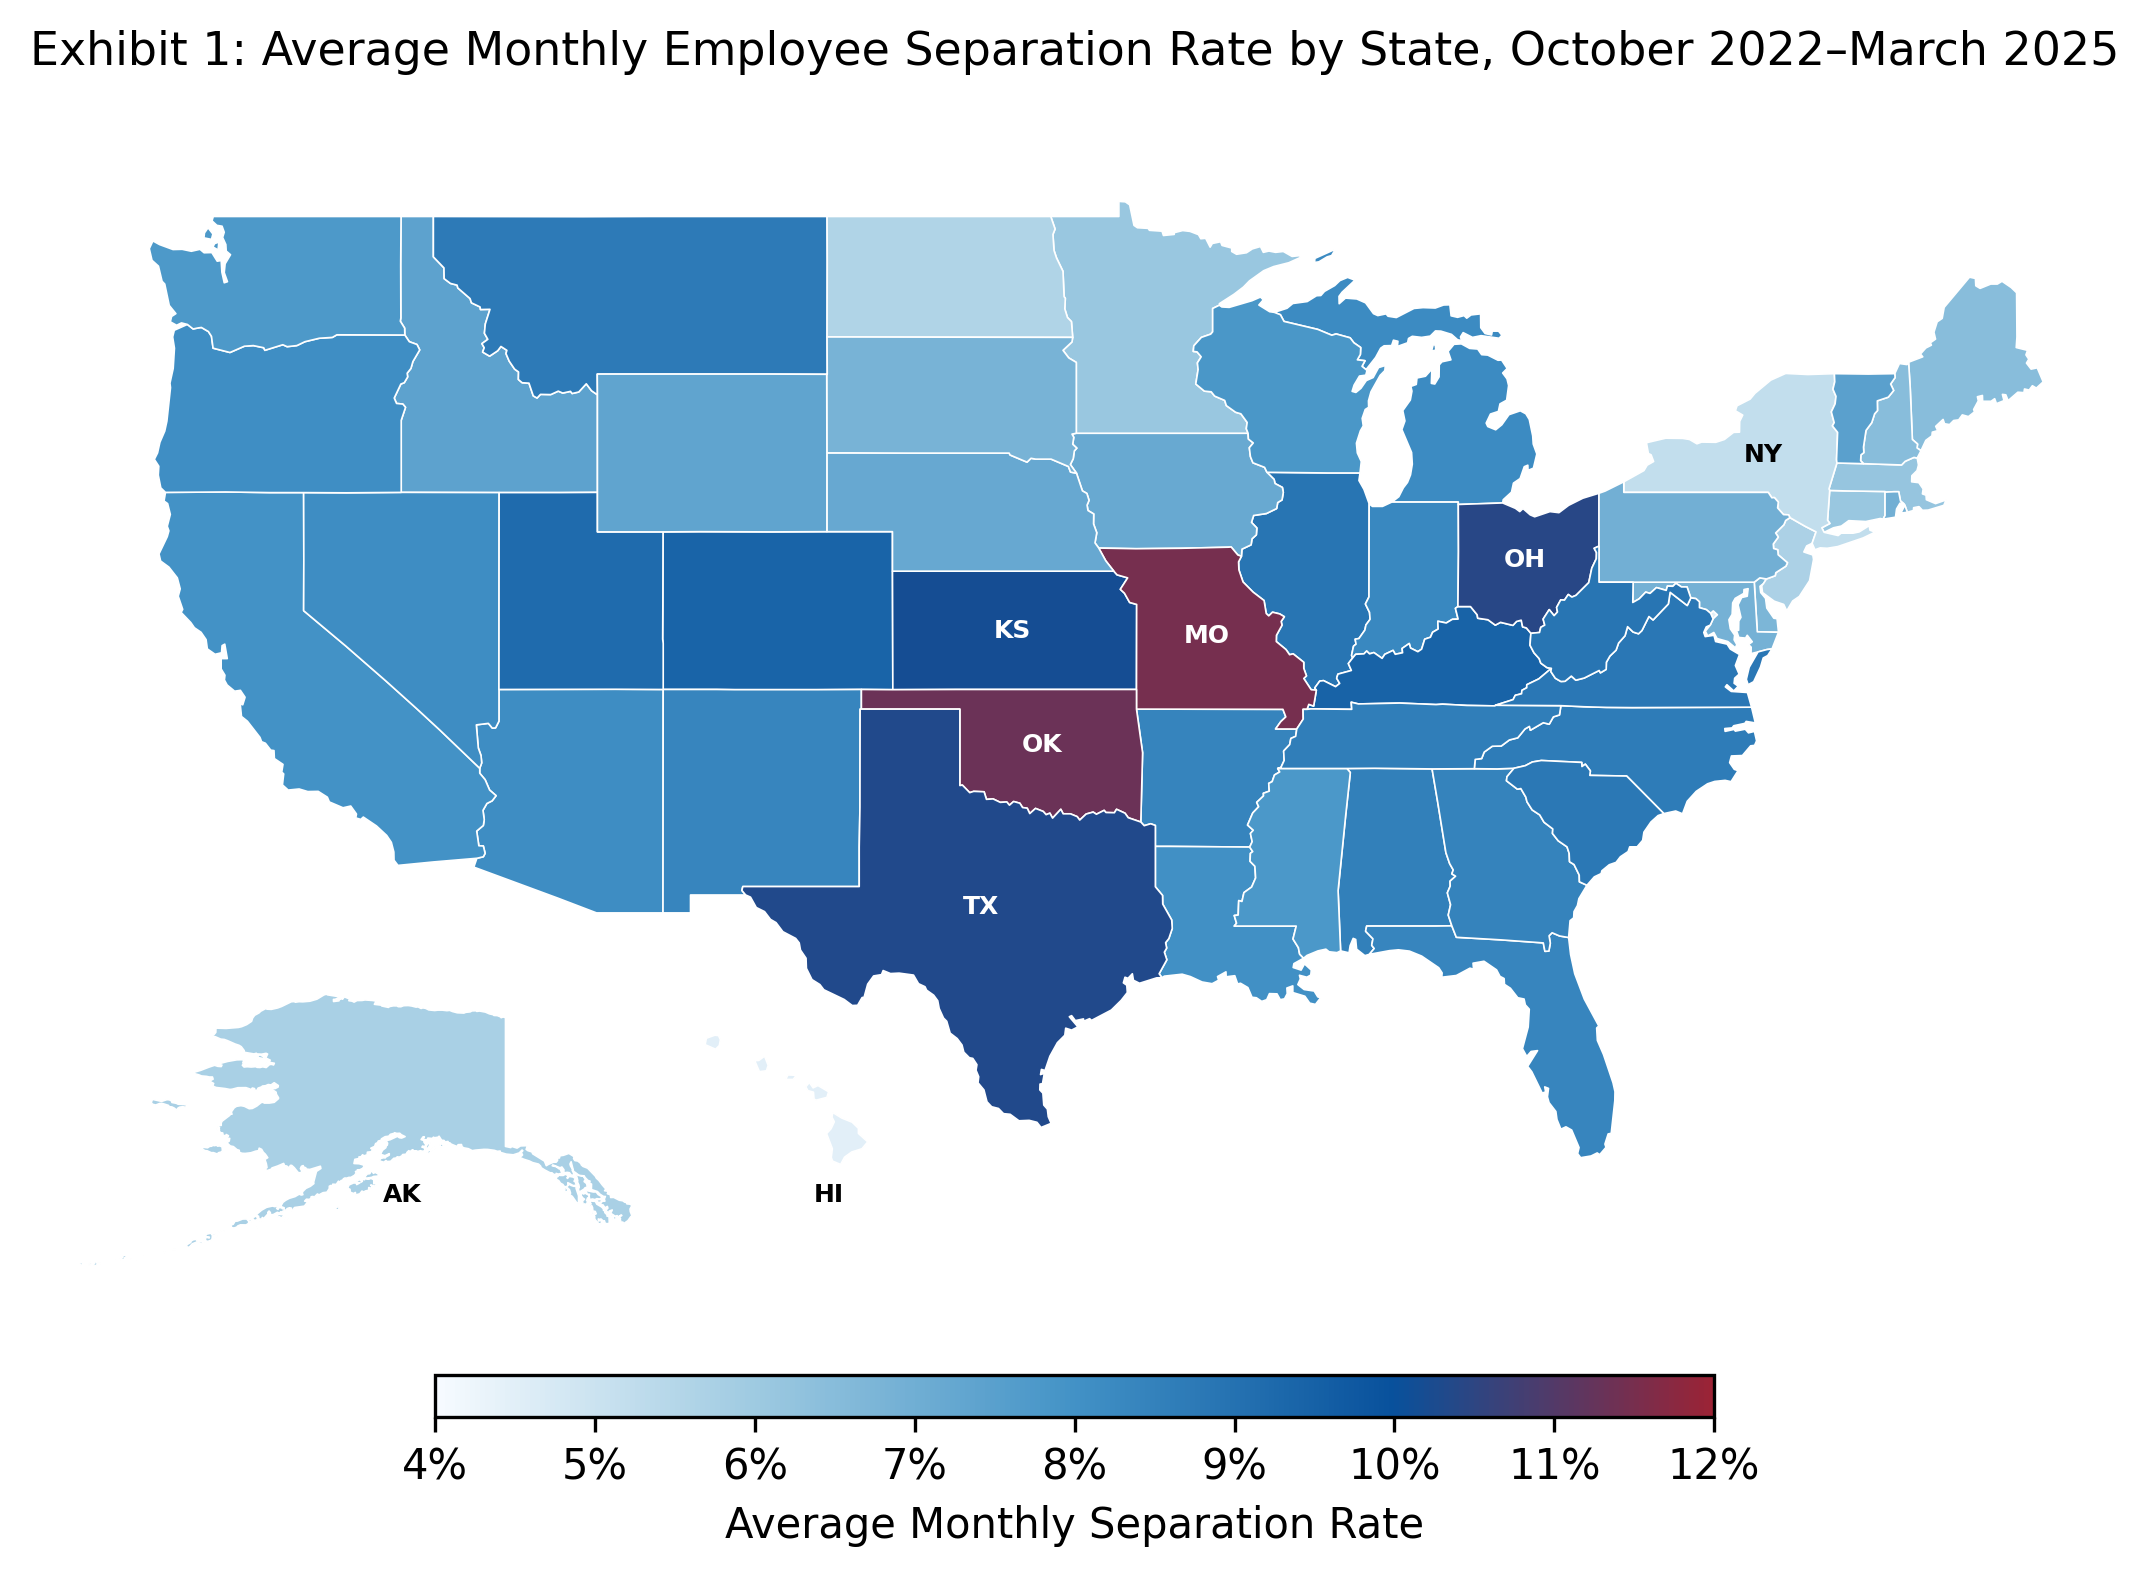

In [6]:
# Exhibit 1: choropleth map of state separation rates (reuses figures/generate_map.py)
import sys; sys.path.insert(0, "../figures")
from generate_map import main as make_exhibit1
make_exhibit1()
from IPython.display import Image
Image("../figures/exhibit1_state_map.png")

# Differences by ownership type
Annualized on the same flow/stock basis as the national figure (12 x workforce-weighted monthly rate).
Friedman across the 3 ownership types (blocked by state-month) + Kendall's W, then a check of how
consistently the gradient holds. For-profit elevation is robust; the full FP>NP>Gov ordering is not
(non-profit and government are close).

In [7]:
from scipy.stats import friedmanchisquare

# Annualized turnover, SAME flow/stock basis as national (12 x workforce-weighted monthly rate)
ow = emp.groupby("ownership").apply(lambda g: g.separation_count.sum() / g.active_count.sum(),
                                    include_groups=False)
for o in ["For-Profit", "Non-Profit", "Government"]:
    print(f"{o:12} monthly {ow[o]*100:.2f}%  annualized {ow[o]*12*100:.0f}%")

# state-month x ownership rates; Friedman across the 3 ownership types
so = emp.groupby(["state", "month_end", "ownership"]).agg(
    seps=("separation_count", "sum"), active=("active_count", "sum")).reset_index()
so["rate"] = so.seps / so.active
w = so.pivot_table(index=["state", "month_end"], columns="ownership", values="rate").dropna()

chi2, pval = friedmanchisquare(w["For-Profit"], w["Non-Profit"], w["Government"])
n_blocks = len(w)
print(f"\nFriedman chi2(2) = {chi2:.0f}, p = {pval:.2e}, Kendall's W = {chi2/(n_blocks*2):.2f}  (blocks={n_blocks})")

# How consistent is the gradient across state-months?
fp_high = (w["For-Profit"] == w.max(axis=1))
full = (w["For-Profit"] > w["Non-Profit"]) & (w["Non-Profit"] > w["Government"])
print(f"For-Profit highest:      {fp_high.mean()*100:.0f}% of state-months")
print(f"Full FP>NP>Gov ordering: {full.mean()*100:.0f}% of state-months")

For-Profit   monthly 8.75%  annualized 105%
Non-Profit   monthly 6.44%  annualized 77%
Government   monthly 6.29%  annualized 75%

Friedman chi2(2) = 1633, p = 0.00e+00, Kendall's W = 0.56  (blocks=1467)
For-Profit highest:      81% of state-months
Full FP>NP>Gov ordering: 62% of state-months


  exhibit2_ownership.png (bar chart)


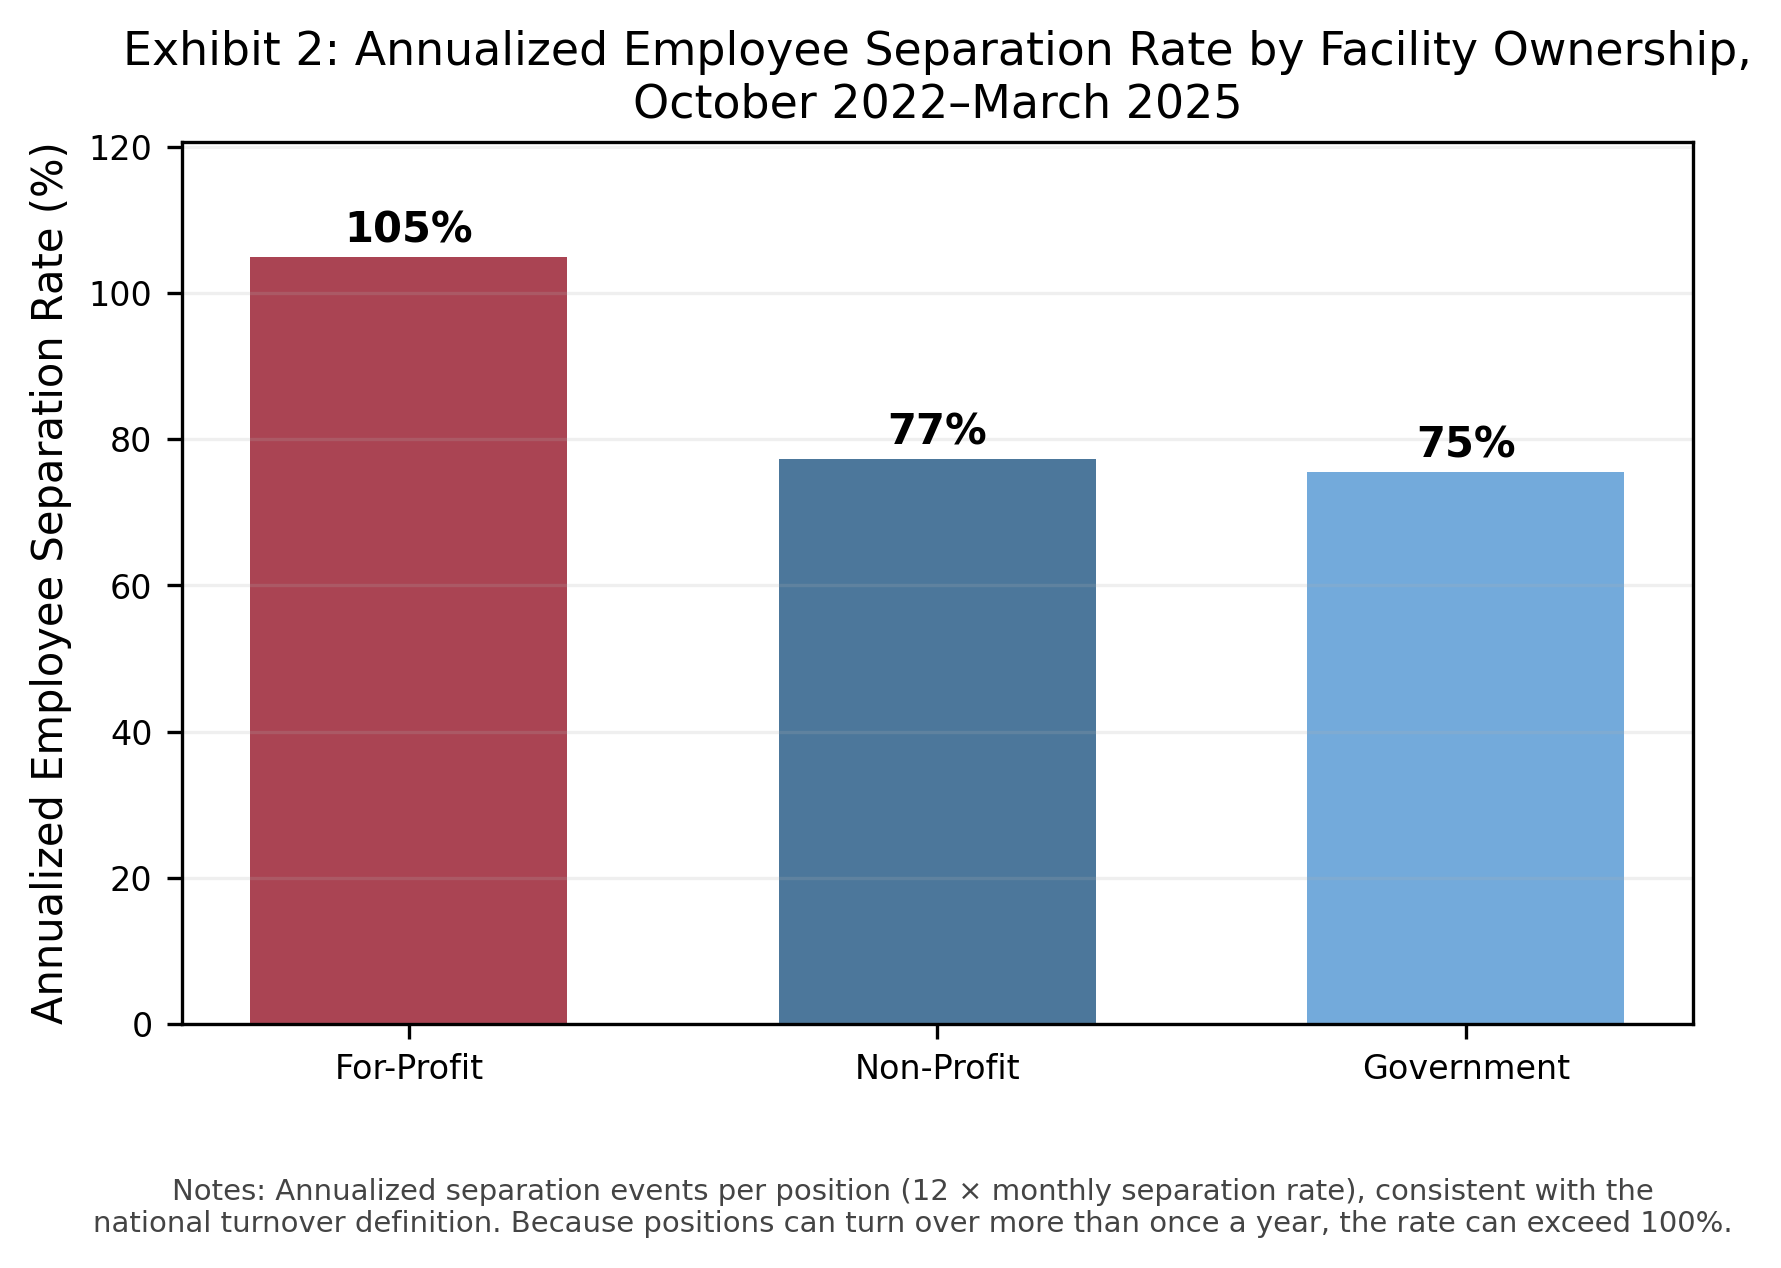

In [8]:
# Exhibit 2: annualized separation rate by ownership (reuses figures/generate_exhibits.py)
import sys; sys.path.insert(0, "../figures")
import generate_exhibits as gx
gx.exhibit2_ownership()
from IPython.display import Image
Image("../figures/exhibit2_ownership.png")

# Differences by nursing role
LPN and RN are close and not consistently ordered, so they are grouped as licensed nurses
(clinically and empirically) and compared against certified nurse aides (CNA).
Two groups -> Wilcoxon signed-rank (paired), reported separately across states and over time;
ownership is a descriptive within-group check. (Kendall's W is degenerate for two groups.)

In [9]:
from scipy.stats import wilcoxon, rankdata

er = emp.copy()
er["grp"] = er.role.map({"CNA": "CNA", "LPN": "Licensed", "RN": "Licensed"})

def _rate(df, keys):
    g = df.groupby(keys).agg(seps=("separation_count", "sum"), active=("active_count", "sum"))
    return (g.seps / g.active)

def _wilcox(a, b):
    """Signed-rank test: returns n, statistic W, p, and rank-biserial effect size."""
    d = (a - b); d = d[d != 0]
    r = rankdata(d.abs()); pos = (d > 0).values
    Wp, Wm = r[pos].sum(), r[~pos].sum()
    res = wilcoxon(a, b)
    return len(a), res.statistic, res.pvalue, (Wp - Wm) / (Wp + Wm)

print("National:", {k: f"{v*100:.2f}%" for k, v in _rate(er, ["grp"]).items()})

# Across STATES (one pair per state, pooled over month & ownership)
st = _rate(er, ["state", "grp"]).unstack().dropna()
n, W, pv, r = _wilcox(st.CNA, st.Licensed)
print(f"By state:  CNA > Licensed in {(st.CNA > st.Licensed).mean()*100:.0f}% of {n} states  |  "
      f"Wilcoxon W = {W:.0f}, p = {pv:.2e}, rank-biserial r = {r:.2f}")

# Over TIME (one pair per month, pooled over state & ownership)
mo = _rate(er, ["month_end", "grp"]).unstack()
n, W, pv, r = _wilcox(mo.CNA, mo.Licensed)
print(f"Over time: CNA > Licensed in {(mo.CNA > mo.Licensed).mean()*100:.0f}% of {n} months  |  "
      f"Wilcoxon W = {W:.0f}, p = {pv:.2e}, rank-biserial r = {r:.2f}")

# By OWNERSHIP (descriptive: national rate within each ownership group)
own = _rate(er, ["ownership", "grp"]).unstack()
for o in ["For-Profit", "Non-Profit", "Government"]:
    print(f"  {o:11}: CNA {own.loc[o,'CNA']*100:.2f}%  vs  Licensed {own.loc[o,'Licensed']*100:.2f}%")

National: {'CNA': '8.61%', 'Licensed': '7.42%'}
By state:  CNA > Licensed in 85% of 52 states  |  Wilcoxon W = 80, p = 2.92e-08, rank-biserial r = 0.88
Over time: CNA > Licensed in 100% of 30 months  |  Wilcoxon W = 0, p = 1.86e-09, rank-biserial r = 1.00
  For-Profit : CNA 9.21%  vs  Licensed 8.03%
  Non-Profit : CNA 6.93%  vs  Licensed 5.63%
  Government : CNA 6.78%  vs  Licensed 5.50%


# Quarter-end temporal pattern
Quarter-end months (Mar/Jun/Sep/Dec) vs the rest of the year, over the full study period.
The paired test controls for the overall trend by comparing each quarter-end month to its
own quarter's baseline (the two non-quarter-end months), then checks consistency across the
10 quarters. Robustness is established by repeating the check across states, ownership, and roles.

In [10]:
import numpy as np
from scipy.stats import wilcoxon

QE_MONTHS = [3, 6, 9, 12]

def monthly_rate(keys):
    g = emp.groupby(keys).agg(seps=("separation_count", "sum"), active=("active_count", "sum"))
    return (g.seps / g.active).rename("rate").reset_index()

# National: quarter-end months vs the remainder of the year (full study period)
nat = monthly_rate(["month_end"])
nat["qend"] = nat.month_end.dt.month.isin(QE_MONTHS)
qe, oth = nat.loc[nat.qend, "rate"].mean(), nat.loc[~nat.qend, "rate"].mean()
print(f"National: quarter-end {qe*100:.2f}% vs remainder {oth*100:.2f}%  (uplift {(qe-oth)*100:.2f}pp)")

# Paired test: each quarter-end month vs its own quarter's baseline (controls for trend)
def quarter_uplift(df):
    df = df.assign(q=df.month_end.dt.to_period("Q"),
                   qend=df.month_end.dt.month.isin(QE_MONTHS))
    ups = [g.loc[g.qend, "rate"].iloc[0] - g.loc[~g.qend, "rate"].mean()
           for _, g in df.groupby("q") if g.qend.sum() == 1 and (~g.qend).sum() == 2]
    ups = np.array(ups)
    return ups.mean(), (ups > 0).sum(), len(ups), wilcoxon(ups).pvalue

m, pos, n, pv = quarter_uplift(nat)
print(f"National paired: uplift {m*100:.2f}pp, positive {pos}/{n} quarters, Wilcoxon p = {pv:.4f}")

# By state: mean quarter-end rate vs mean remainder rate, tested across states
st = monthly_rate(["state", "month_end"])
st["qend"] = st.month_end.dt.month.isin(QE_MONTHS)
per = st.groupby(["state", "qend"]).rate.mean().unstack().dropna()
w = wilcoxon(per[True], per[False])
print(f"By state: positive in {(per[True] > per[False]).sum()}/{len(per)} states, Wilcoxon p = {w.pvalue:.2e}")

# By ownership and by role: paired quarter test within each group
for dim in ["ownership", "role"]:
    print(f"By {dim}:")
    for key, g in monthly_rate([dim, "month_end"]).groupby(dim):
        m, pos, n, pv = quarter_uplift(g)
        print(f"  {key:11}: uplift {m*100:.2f}pp, {pos}/{n} quarters, p = {pv:.4f}")

National: quarter-end 9.25% vs remainder 7.61%  (uplift 1.64pp)
National paired: uplift 1.64pp, positive 10/10 quarters, Wilcoxon p = 0.0020
By state: positive in 53/53 states, Wilcoxon p = 2.39e-10
By ownership:
  For-Profit : uplift 1.65pp, 10/10 quarters, p = 0.0020
  Government : uplift 1.67pp, 10/10 quarters, p = 0.0020
  Non-Profit : uplift 1.60pp, 10/10 quarters, p = 0.0020
By role:
  CNA        : uplift 1.52pp, 10/10 quarters, p = 0.0020
  LPN        : uplift 1.75pp, 10/10 quarters, p = 0.0020
  RN         : uplift 1.91pp, 10/10 quarters, p = 0.0020


# Export supplementary data
Single master aggregate at state x month x ownership x role (Employee population).
All three findings (geography, ownership, role) roll up from this one file.
See the README in `docs/supplementary_files/` for the data dictionary and roll-up notes.

In [11]:
from pathlib import Path

out_dir = Path("../docs/supplementary_files")
out_dir.mkdir(parents=True, exist_ok=True)

master = (emp.groupby(["state", "month_end", "ownership", "role"])
          .agg(separation=("separation_count", "sum"),
               active_headcount=("active_count", "sum"))
          .reset_index()
          .rename(columns={"month_end": "month"}))
master["separation_rate"] = master.separation / master.active_headcount
master["month"] = master.month.dt.strftime("%Y-%m-%d")

path = out_dir / "separation_rates_state_month_ownership_role.csv"
master.to_csv(path, index=False)
print(f"Wrote {path}: {len(master)} rows "
      f"({master.state.nunique()} states x {master.month.nunique()} months "
      f"x {master.ownership.nunique()} ownership x {master.role.nunique()} roles)")

Wrote ../docs/supplementary_files/separation_rates_state_month_ownership_role.csv: 13764 rows (53 states x 30 months x 3 ownership x 3 roles)


# Rolling-origin backtest
Triggers the seasonal-naive rolling-origin backtest (5 expanding windows, 3-month horizon
each) against a persistence baseline. Reuses `model/rolling_backtest.py` (single source of
truth), writes `model/output/rolling_backtest_summary.csv`, and prints the per-origin
workforce-weighted MAE. Seasonal-naive should beat persistence at every origin.

In [12]:
import sys
sys.path.insert(0, "../model")
from rolling_backtest import main as run_rolling_backtest

run_rolling_backtest()

    origin    n  seasonal_naive_wMAE_pp  persistence_wMAE_pp
2024-03-01 1281                1.321382             1.932076
2024-06-01 1281                1.236420             1.538244
2024-09-01 1278                1.501146             1.669369
2024-12-01 1278                1.083914             1.201102
2025-03-01 1278                1.072280             1.425885
    POOLED 6396                1.241810             1.550425

Done.


# Generate seasonal-naive forecasts
Runs the forecaster (`model/seasonal_naive.py`) to (re)create
`model/output/seasonal_naive_forecast_rates.csv`, which the validation and Exhibit 3/4
cells below consume. Run this once before those cells on a fresh checkout.

In [13]:
import sys; sys.path.insert(0, "../model")
from seasonal_naive import main as generate_forecasts
_ = generate_forecasts()

Wrote /Users/bsmalla/PycharmProjects/nursing_home_staffing/eda/../model/output/seasonal_naive_forecast_rates.csv: 791 series, 9486 rows
        ds  forecast  forecast_lo95  forecast_hi95
2025-04-01  0.072470       0.064380       0.080560
2025-05-01  0.077101       0.069011       0.085191
2025-06-01  0.089508       0.081418       0.097598
2025-07-01  0.076090       0.068000       0.084180
2025-08-01  0.079645       0.071555       0.087735
2025-09-01  0.087777       0.079687       0.095867


# Forecast validation (national)
Held-out months (Apr-Jun 2025): seasonal-naive forecast vs observed, with 80% / 95%
prediction intervals. Observed uses the full panel `p` (validation months fall outside the
training window `emp`).

In [14]:
fc = pd.read_csv("../model/output/seasonal_naive_forecast_rates.csv", parse_dates=["ds"])
nat_fc = fc[fc.unique_id == "National/total/total"].set_index("ds")

# Observed national rate (Employee, workforce-weighted); full panel incl. validation months
obs = (p[p.worker_type == "Employee"].groupby("month_end")
       .apply(lambda g: g.separation_count.sum() / g.active_count.sum(), include_groups=False))

print(f"{'month':>10}  {'fcst':>6}  {'obs':>6}  {'80% PI':>14}  {'95% PI':>14}  within95")
for mth in ["2025-04-01", "2025-05-01", "2025-06-01"]:
    d = pd.Timestamp(mth); r = nat_fc.loc[d]; o = obs[d]
    in95 = r["forecast_lo95"] <= o <= r["forecast_hi95"]
    print(f"{mth:>10}  {r.forecast*100:5.2f}%  {o*100:5.2f}%  "
          f"[{r['forecast_lo80']*100:.1f}, {r['forecast_hi80']*100:.1f}]  "
          f"[{r['forecast_lo95']*100:.1f}, {r['forecast_hi95']*100:.1f}]  {in95}")

     month    fcst     obs          80% PI          95% PI  within95
2025-04-01   7.25%   7.14%  [6.7, 7.8]  [6.4, 8.1]  True
2025-05-01   7.71%   7.55%  [7.2, 8.2]  [6.9, 8.5]  True
2025-06-01   8.95%   8.86%  [8.4, 9.5]  [8.1, 9.8]  True


  exhibit3_national_forecast.png


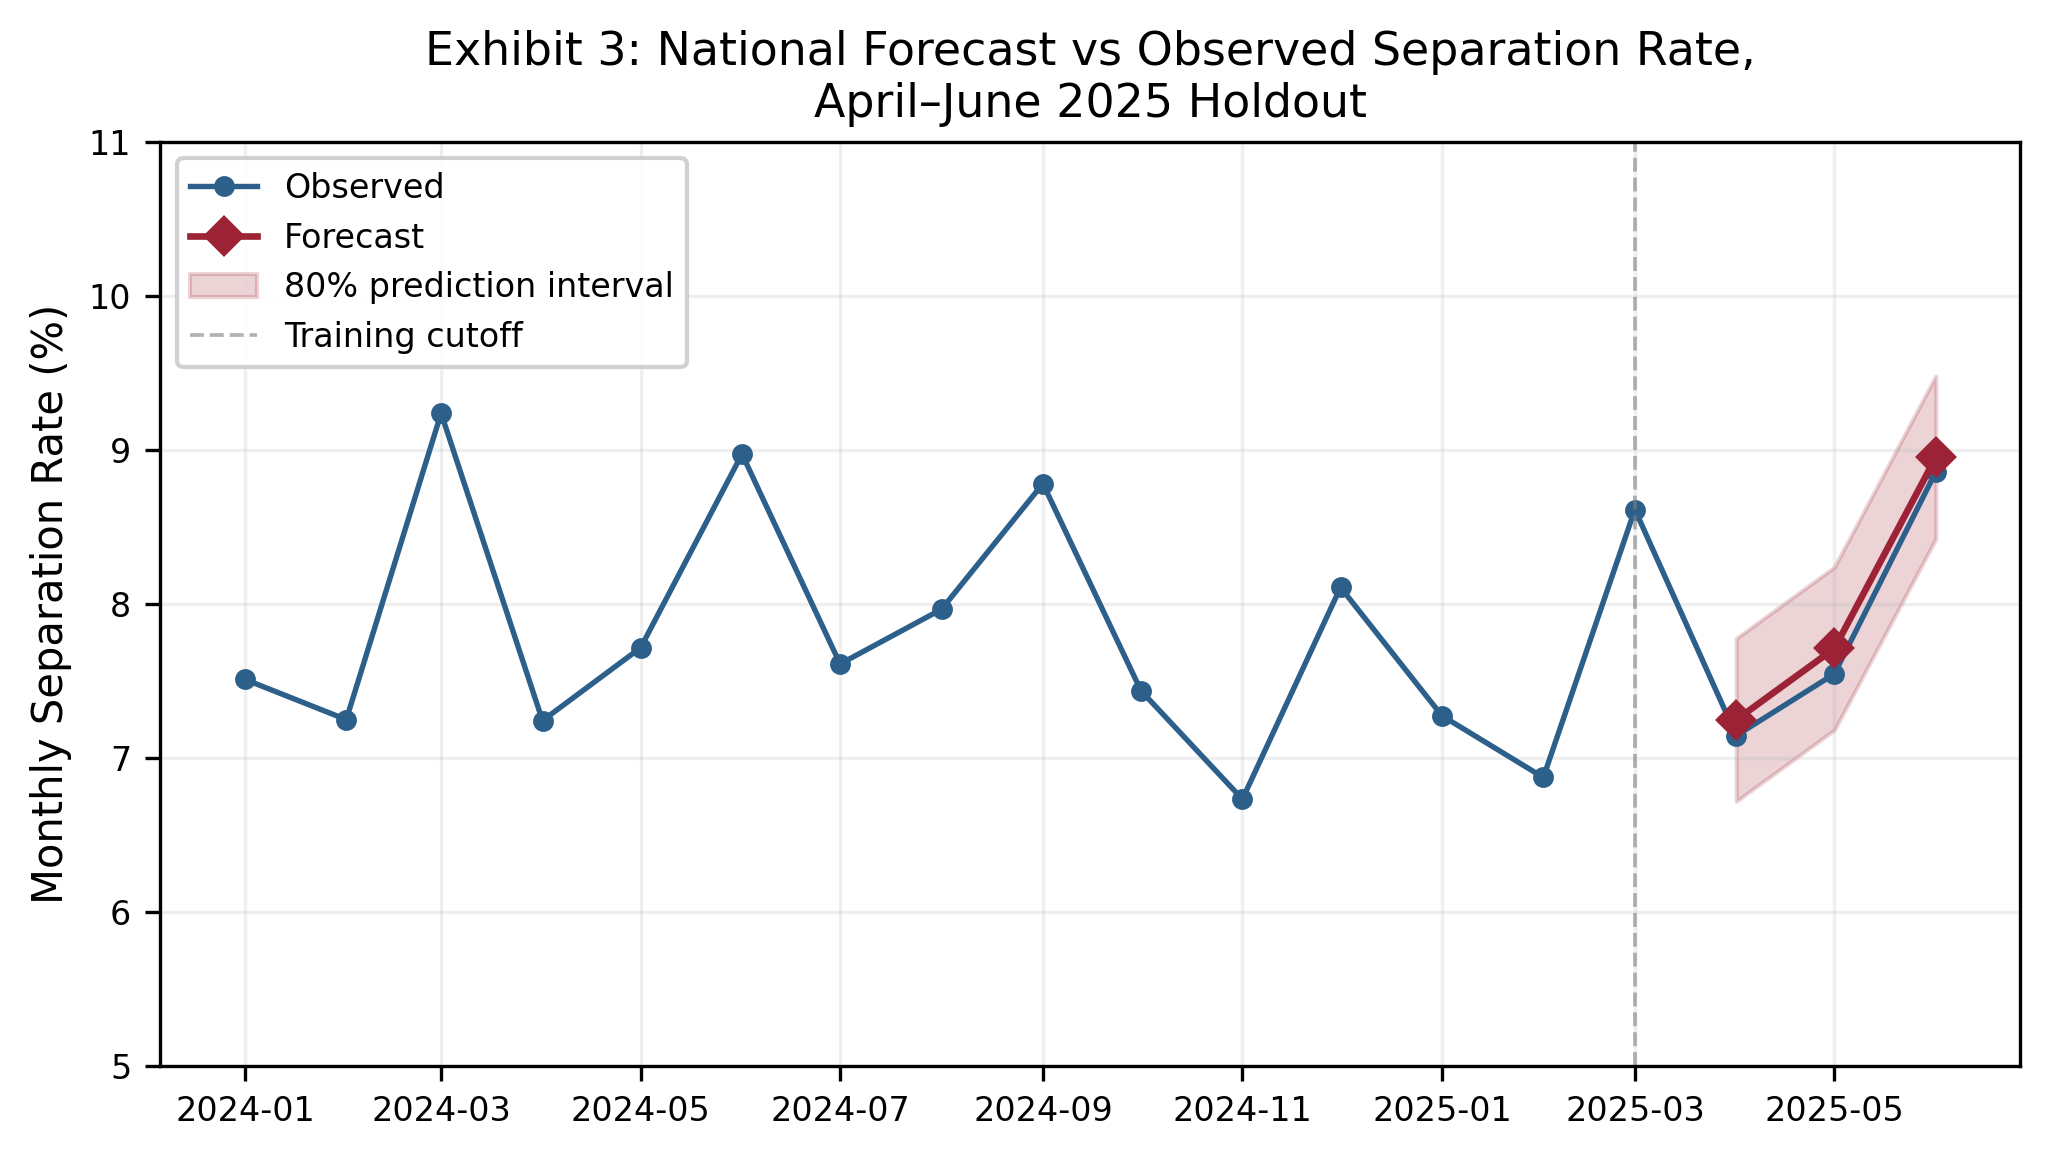

In [15]:
# Exhibit 3: national forecast vs observed with 80% PI (reuses figures/generate_exhibits.py)
import sys; sys.path.insert(0, "../figures")
import generate_exhibits as gx
gx.exhibit3_national_forecast()
from IPython.display import Image
Image("../figures/exhibit3_national_forecast.png")

# Forecast validation (state-level)
Held-out months (Apr-Jun 2025) for high-risk (Missouri, Texas) and low-risk (New York)
states: state-total forecast vs observed with 95% prediction interval. Backs the state
examples and the contrast that New York sits in a substantially lower range.

In [16]:
def obs_state(s):
    d = p[(p.worker_type == "Employee") & (p.state == s)]
    return d.groupby("month_end").apply(lambda g: g.separation_count.sum() / g.active_count.sum(),
                                        include_groups=False)

for s in ["MO", "TX", "NY"]:
    f = fc[fc.unique_id == f"{s}/total/total"].set_index("ds")
    o = obs_state(s)
    print(f"{s}  (validation-period avg observed {o[[pd.Timestamp(m) for m in ['2025-04-01','2025-05-01','2025-06-01']]].mean()*100:.1f}%):")
    for mth in ["2025-04-01", "2025-05-01", "2025-06-01"]:
        d = pd.Timestamp(mth); r = f.loc[d]; ov = o[d]
        in95 = r["forecast_lo95"] <= ov <= r["forecast_hi95"]
        print(f"  {mth}  fcst {r.forecast*100:5.2f}%  obs {ov*100:5.2f}%  "
              f"95% PI [{r['forecast_lo95']*100:.1f}, {r['forecast_hi95']*100:.1f}]  within95={in95}")

MO  (validation-period avg observed 11.4%):
  2025-04-01  fcst 10.05%  obs 10.33%  95% PI [8.3, 11.8]  within95=True
  2025-05-01  fcst 11.61%  obs 11.50%  95% PI [9.9, 13.3]  within95=True
  2025-06-01  fcst 12.00%  obs 12.28%  95% PI [10.3, 13.7]  within95=True
TX  (validation-period avg observed 10.1%):
  2025-04-01  fcst  8.88%  obs  9.27%  95% PI [7.0, 10.7]  within95=True
  2025-05-01  fcst  9.45%  obs  9.84%  95% PI [7.6, 11.3]  within95=True
  2025-06-01  fcst 10.77%  obs 11.14%  95% PI [8.9, 12.6]  within95=True
NY  (validation-period avg observed 5.8%):
  2025-04-01  fcst  4.86%  obs  5.04%  95% PI [4.3, 5.5]  within95=True
  2025-05-01  fcst  4.98%  obs  5.65%  95% PI [4.4, 5.6]  within95=False
  2025-06-01  fcst  6.10%  obs  6.63%  95% PI [5.5, 6.7]  within95=True


# State size vs turnover (Exhibit 4 dimensions)
Are the two axes of Exhibit 4 related? Workforce size (active employees in the last training
month, matching the figure) vs forecasted turnover across the 52 states, plus a large/small
median-split comparison and the highlighted-state values.

In [17]:
from scipy.stats import spearmanr, mannwhitneyu

# State workforce size = active employees in the last training month (Exhibit 4 definition)
size = emp[emp.month_end == "2025-03-01"].groupby("state").active_count.sum()
obs_rate = emp.groupby("state").apply(lambda g: g.separation_count.sum() / g.active_count.sum(),
                                      include_groups=False)
sf = fc[fc.unique_id.str.match(r"^[A-Z]{2}/total/total$")].copy()
sf["state"] = sf.unique_id.str[:2]
fcst = sf[sf.ds <= "2025-06-01"].groupby("state").forecast.mean()

d = pd.DataFrame({"size": size, "obs": obs_rate, "fcst": fcst}).dropna()

rho, pv = spearmanr(d["size"], d["fcst"])
print(f"n={len(d)} states | size vs forecast: Spearman rho={rho:.2f}, p={pv:.2f}")

med = d["size"].median()
large, small = d[d["size"] >= med].obs, d[d["size"] < med].obs
u = mannwhitneyu(large, small)
print(f"Large vs small states: observed {large.mean()*100:.1f}% vs {small.mean()*100:.1f}%, "
      f"Mann-Whitney p={u.pvalue:.2f}")

print("\nExhibit 4 highlighted states (workforce '000s, forecast rate):")
for s in ["MO", "OK", "OH", "TX"]:
    print(f"  {s}: {d.loc[s,'size']/1000:.1f}k, {d.loc[s,'fcst']*100:.1f}%")

n=52 states | size vs forecast: Spearman rho=0.32, p=0.02
Large vs small states: observed 8.2% vs 7.3%, Mann-Whitney p=0.09

Exhibit 4 highlighted states (workforce '000s, forecast rate):
  MO: 26.6k, 11.2%
  OK: 15.0k, 11.1%
  OH: 60.4k, 9.9%
  TX: 67.6k, 9.7%


  exhibit4_state_quadrant.png


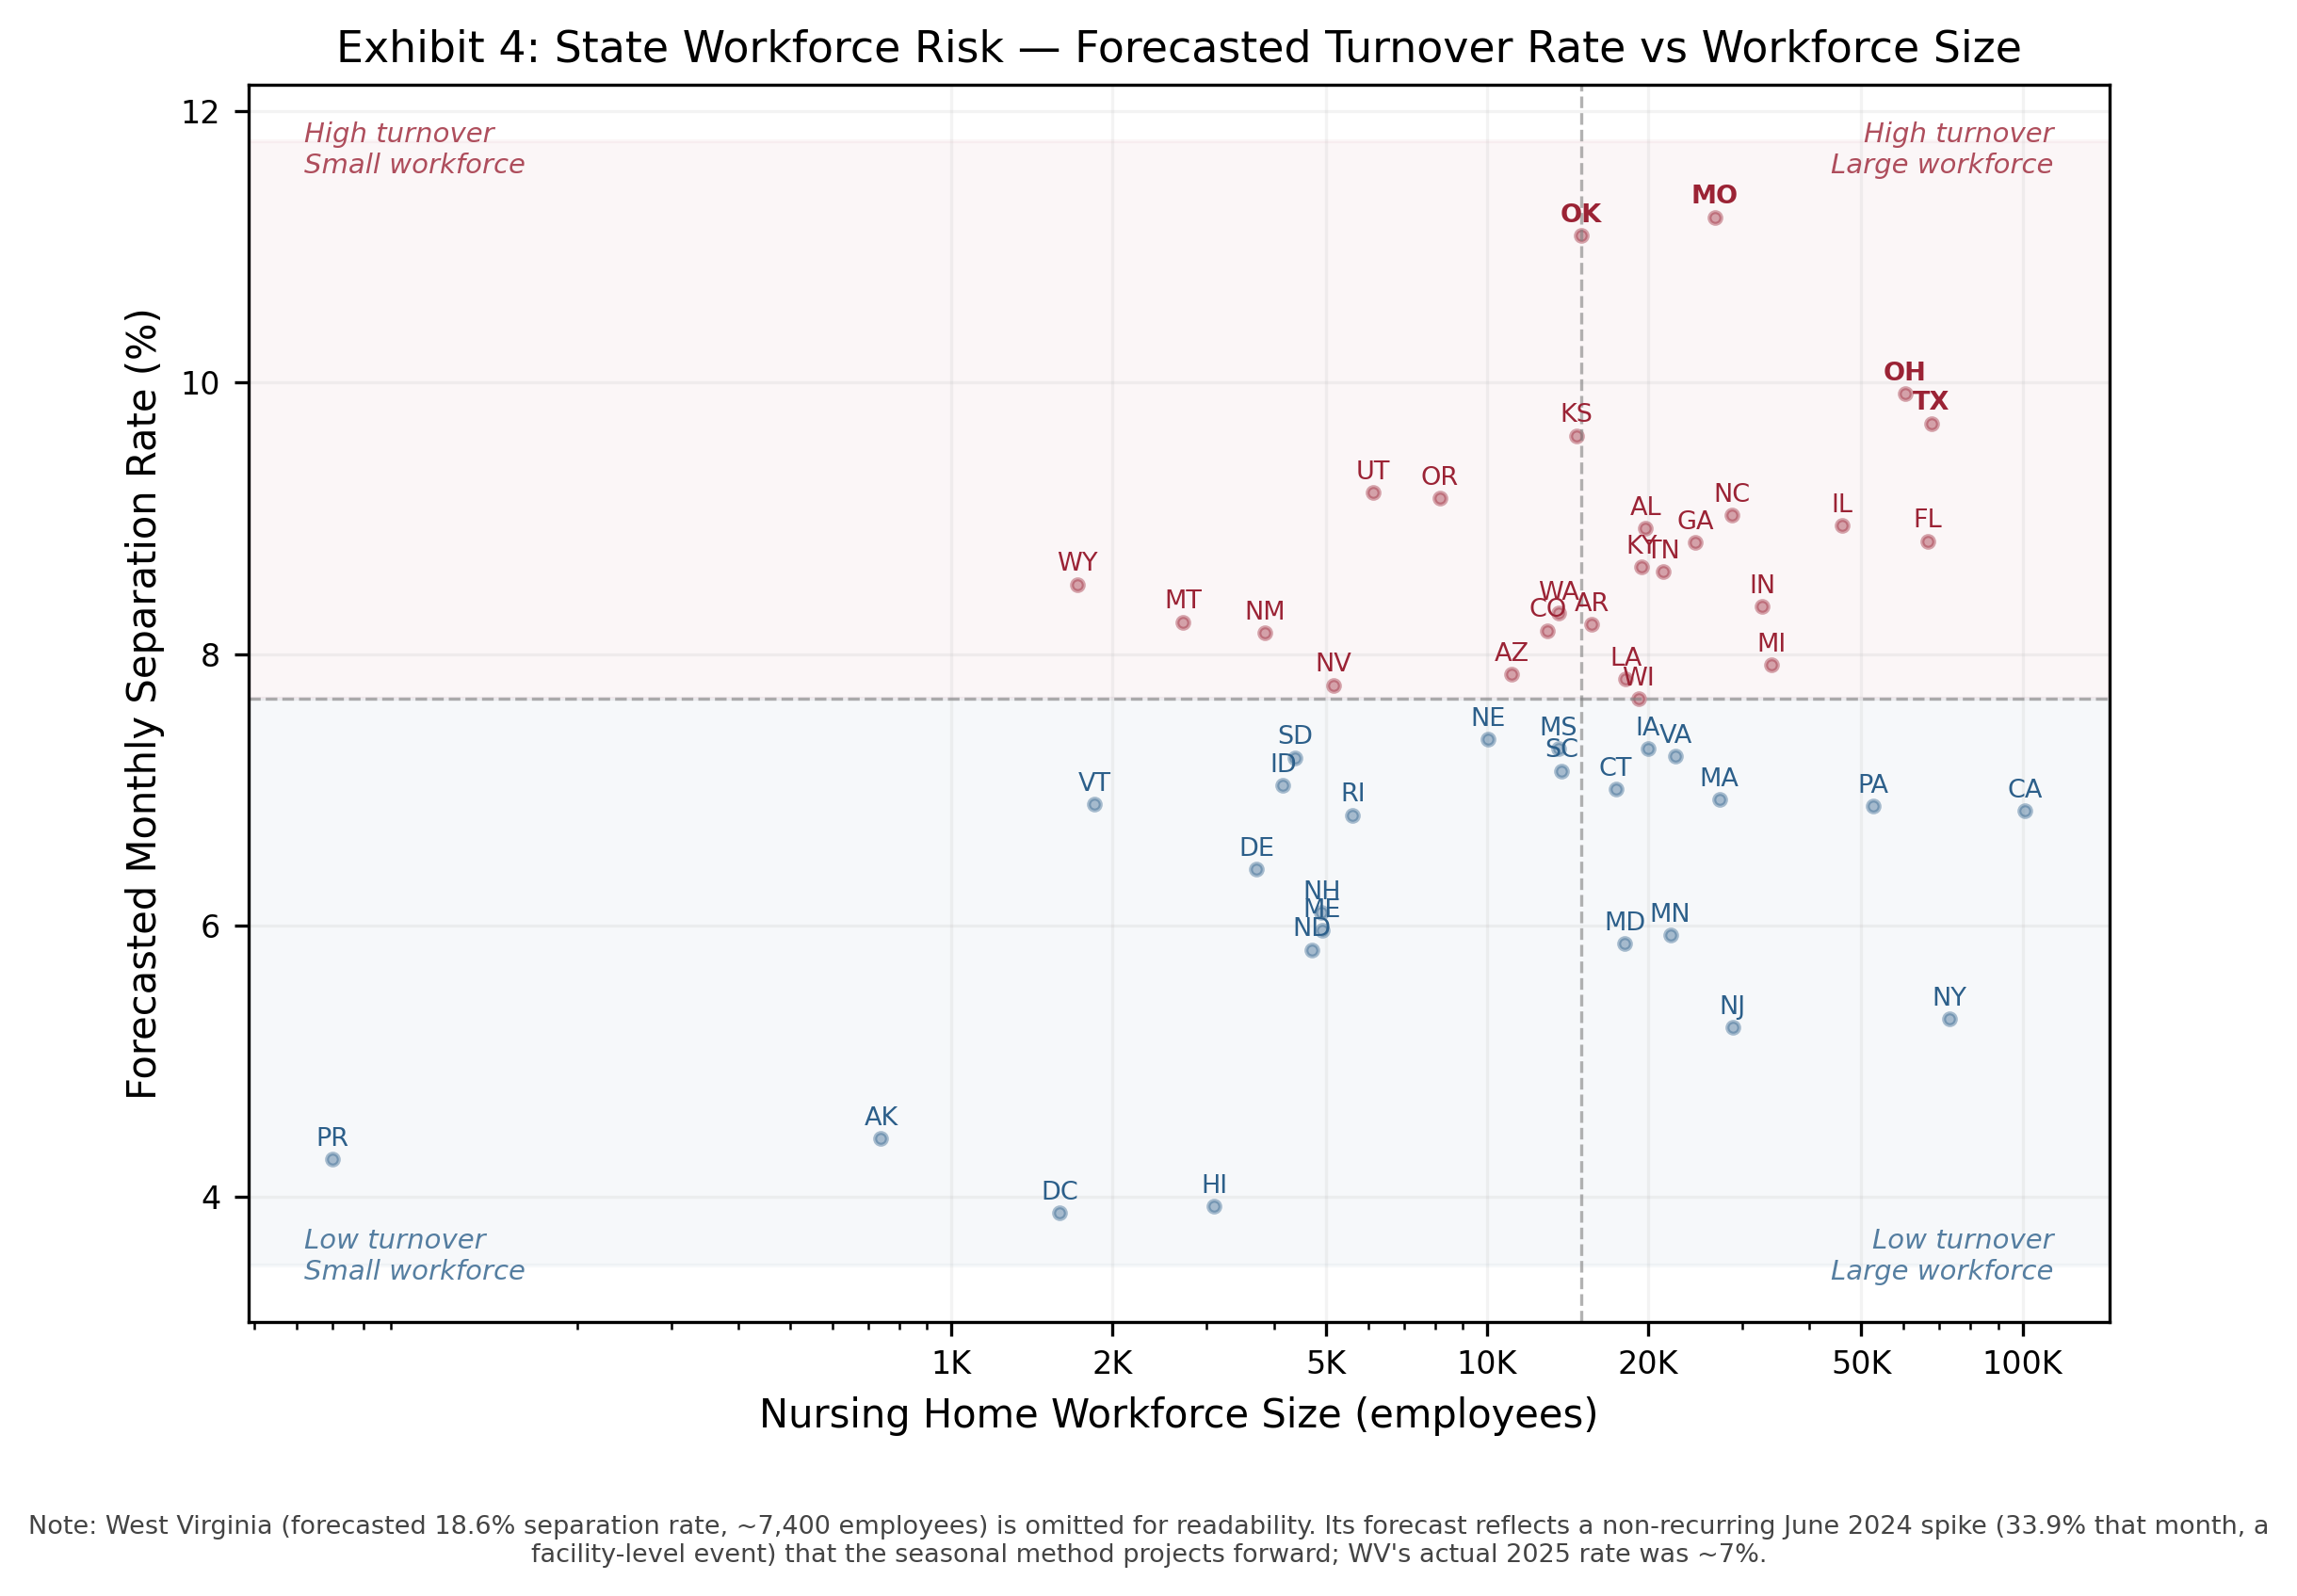

In [18]:
# Exhibit 4: state risk quadrant, forecast rate vs workforce size (reuses figures/generate_exhibits.py)
import sys; sys.path.insert(0, "../figures")
import generate_exhibits as gx
gx.exhibit4_state_forecast()
from IPython.display import Image
Image("../figures/exhibit4_state_quadrant.png")